<a href="https://colab.research.google.com/github/Gagandeep1227/ML-2/blob/main/Bagging_and_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   Age  Salary  Experience    Purchased
0   25   30000           1   No        
1   35   60000           5   Yes       
2   42   80000          10   Yes       
3   23   25000           1   No        

Dataset Shape: (4, 4)

MODEL PERFORMANCE COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score
0   Bagging       1.0        1.0     1.0       1.0
1  Boosting       1.0        1.0     1.0       1.0


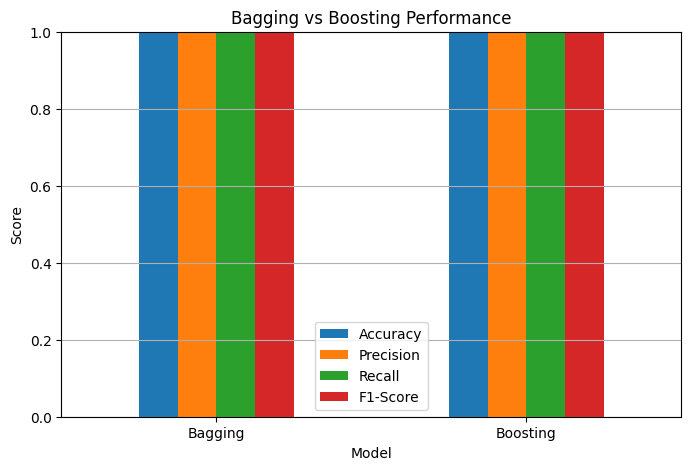

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = pd.read_csv("/content/bagging.csv", sep='|', skiprows=[1])

data = data.iloc[:, 1:-1]

data.columns = data.columns.str.strip()

print("Dataset:")
print(data.head())

print("\nDataset Shape:", data.shape)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X = pd.get_dummies(X, drop_first=True)

if y.dtype == 'object':
    encoder = LabelEncoder()
    y = encoder.fit_transform(y)

imputer = SimpleImputer(strategy="most_frequent")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.50,
    random_state=42,
    stratify=y
)


bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)

boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

boosting_model.fit(X_train, y_train)

y_pred_boosting = boosting_model.predict(X_test)


def evaluate_model(name, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, average="weighted", zero_division=0
    )

    return [name, accuracy, precision, recall, f1]


bagging_results = evaluate_model(
    "Bagging",
    y_test,
    y_pred_bagging
)

boosting_results = evaluate_model(
    "Boosting",
    y_test,
    y_pred_boosting
)

results = pd.DataFrame(
    [bagging_results, boosting_results],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\n===================================")
print("MODEL PERFORMANCE COMPARISON")
print("===================================")

print(results)


results.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

Notebook loaded successfully!

Code found in notebook:
data1=pd.read_csv('../input/breast-cancer/data.csv')

CSV files available in Colab:
/content/bagging.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv

Using dataset:
/content/bagging.csv

Dataset loaded successfully!

First 5 rows:
   Age  Salary  Experience    Purchased
0   25   30000           1   No        
1   35   60000           5   Yes       
2   42   80000          10   Yes       
3   23   25000           1   No        

Dataset shape:
(4, 4)

Column names:
['Age', 'Salary', 'Experience', 'Purchased']

Target column:
Purchased

Target classes:
0 =  No        
1 =  Yes       

Training samples:
2

Testing samples:
2


          BAGGING vs BOOSTING
   Model  Accuracy  Precision  Recall  F1-Score
 Bagging       1.0        1.0     1.0       1.0
Boosting       1.0        1.0     1.0       1.0


BAG

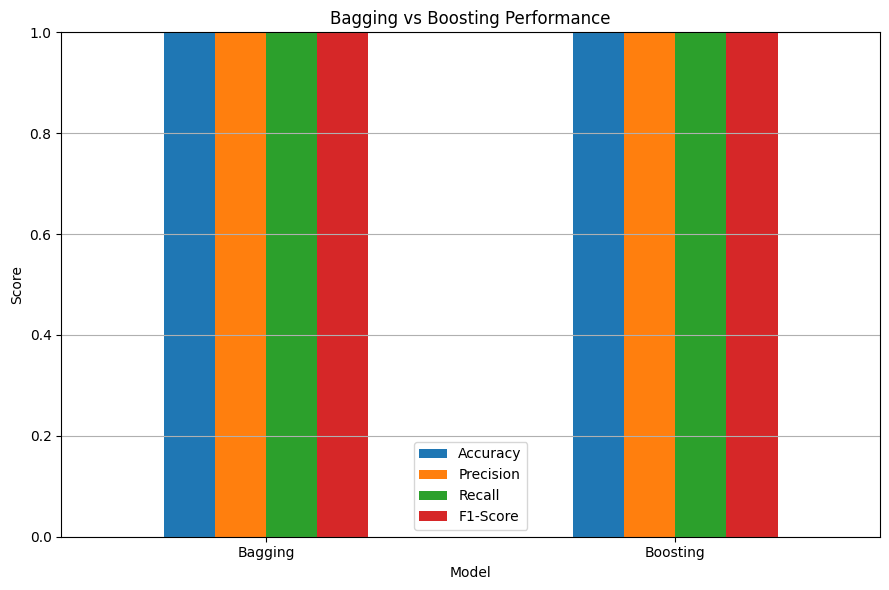



EXPERIMENT COMPLETED SUCCESSFULLY

Model: Bagging
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Model: Boosting
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [19]:
import json
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

notebook_path = "/content/breast-cancer-wisconsin.ipynb"

with open(notebook_path, "r", encoding="utf-8") as file:
    notebook = json.load(file)

print("Notebook loaded successfully!")

csv_name = None

for cell in notebook["cells"]:

    if cell["cell_type"] == "code":

        code = "".join(cell["source"])

        if "read_csv" in code:

            print("\nCode found in notebook:")
            print(code)

            # Look for data.csv
            if "data.csv" in code:
                csv_name = "data.csv"

if csv_name is not None:

    possible_files = glob.glob("/content/**/*.csv", recursive=True)

    print("\nCSV files available in Colab:")

    for file in possible_files:
        print(file)

else:

    raise FileNotFoundError(
        "Could not find CSV information inside the notebook."
    )

if os.path.exists("/content/bagging.csv"):

    dataset_path = "/content/bagging.csv"

elif os.path.exists("/content/data.csv"):

    dataset_path = "/content/data.csv"

else:

    raise FileNotFoundError(
        "Please upload the actual CSV dataset."
    )


print("\nUsing dataset:")
print(dataset_path)


# Read CSV with correct parameters for bagging.csv
data = pd.read_csv(dataset_path, sep='|', skiprows=[1])

# Drop the first and last unnamed columns that result from the leading/trailing pipes
data = data.iloc[:, 1:-1]

# Strip whitespace from column names
data.columns = data.columns.str.strip()

print("\nDataset loaded successfully!")

print("\nFirst 5 rows:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns.tolist())

data = data.loc[
    :,
    ~data.columns.astype(str).str.contains(
        "^Unnamed",
        case=False
    )
]


if "id" in data.columns:

    data = data.drop(
        "id",
        axis=1
    )

if "diagnosis" in data.columns:

    target_column = "diagnosis"

else:

    target_column = data.columns[-1]


print("\nTarget column:")
print(target_column)

X = data.drop(
    target_column,
    axis=1
)

y = data[target_column]

X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

X = X.fillna(
    X.median()
)

if y.dtype == "object":

    encoder = LabelEncoder()

    y = encoder.fit_transform(y)

    print("\nTarget classes:")

    for number, label in enumerate(
        encoder.classes_
    ):

        print(
            number,
            "=",
            label
        )

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.50, # Changed from 0.20 to 0.50 to ensure at least 2 test samples for stratification

    random_state=42,

    stratify=y
)


print("\nTraining samples:")
print(X_train.shape[0])

print("\nTesting samples:")
print(X_test.shape[0])

bagging_model = BaggingClassifier(

    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    n_estimators=100,

    random_state=42
)

bagging_model.fit(
    X_train,
    y_train
)

y_pred_bagging = bagging_model.predict(
    X_test
)

boosting_model = AdaBoostClassifier(

    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),

    n_estimators=100,

    learning_rate=1.0,

    random_state=42
)

boosting_model.fit(
    X_train,
    y_train
)


# Predict

y_pred_boosting = boosting_model.predict(
    X_test
)

def evaluate_model(
    model_name,
    y_test,
    y_pred
):

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ]

bagging_results = evaluate_model(

    "Bagging",

    y_test,

    y_pred_bagging
)

boosting_results = evaluate_model(

    "Boosting",

    y_test,

    y_pred_boosting
)

results = pd.DataFrame(

    [
        bagging_results,
        boosting_results
    ],

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)


print("\n")
print("=" * 70)
print("          BAGGING vs BOOSTING")
print("=" * 70)

print(
    results.to_string(
        index=False
    )
)

print("\n")
print("=" * 70)
print("BAGGING CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_bagging,
        zero_division=0
    )
)

print("\n")
print("=" * 70)
print("BOOSTING CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred_boosting,
        zero_division=0
    )
)

print("\nBagging Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_bagging
    )
)


print("\nBoosting Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_boosting
    )
)

results.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Bagging vs Boosting Performance"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

print("\n")
print("=" * 70)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("=" * 70)

for _, row in results.iterrows():

    print("\nModel:", row["Model"])

    print(
        "Accuracy  : {:.4f}".format(
            row["Accuracy"]
        )
    )

    print(
        "Precision : {:.4f}".format(
            row["Precision"]
        )
    )

    print(
        "Recall    : {:.4f}".format(
            row["Recall"]
        )
    )

    print(
        "F1-Score  : {:.4f}".format(
            row["F1-Score"]
        )
    )